<a href="https://colab.research.google.com/github/ahmedinB/Computer-Vision-Fundamentals/blob/main/RCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install selectivesearch torch_snippets kagglehub

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.3/110.3 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.4/91.4 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.4/226.4 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 133.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.0/469.0 kB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 128.1 MB/s eta 0:00:00
  Created wheel for selectivesearch: filena

In [ ]:
from torch_snippets import logger, show
import selectivesearch
from torchvision import transforms, models, datasets
from torchvision.ops import nms
import numpy as np
import pandas as pd
import cv2
from torch.utils.data import Dataset
import matplotlib.pyplot as plt

In [ ]:
import kagglehub
trucks_and_buses = kagglehub.dataset_download('sixhky/open-images-bus-trucks')
print('Trucks and buses dataset download complete at :' , trucks_and_buses)

100%|██████████| 367M/367M [00:02<00:00, 138MB/s]

Extracting files...


Trucks and buses dataset download complete at : /root/.cache/kagglehub/datasets/sixhky/open-images-bus-trucks/versions/1


In [ ]:
def extract_candidates(img):
  img_lbl, regions = selectivesearch.selective_search(img, scale=500, min_size=100)
  img_area = np.prod(img.shape[:2])
  candidates = []

  for r in regions:
    if r['rect'] in candidates: continue
    if r['size'] < (0.05* img_area): continue
    if r['size'] > (1*img_area): continue
    x, y, w, h = r['rect']
    candidates.append(list(r['rect']))

  return candidates


In [ ]:
def extract_iou(boxA, boxB, epsilon=1e-5):

  x1 = max(boxA[0], boxB[0])
  y1 = max(boxA[1], boxB[1])
  x2 = min(boxA[2], boxB[2])
  y2 = min(boxA[3], boxB[3])

  width = (x2 - x1)
  height = (y2 - y1)

  if (width < 0) or (height < 0):
    return 0

  area_overlap = width*height

  area_a = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
  area_b = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

  area_combined = area_a + area_b - area_overlap
  iou = area_overlap / (area_combined + epsilon)
  return iou

In [ ]:
IMAGE_ROOT = '/root/.cache/kagglehub/datasets/sixhky/open-images-bus-trucks/versions/1/images/images'
DF_RAW = pd.read_csv('/root/.cache/kagglehub/datasets/sixhky/open-images-bus-trucks/versions/1/df.csv')
DF_RAW.head()

,ImageID,Source,LabelName,Confidence,XMin,XMax,YMin,YMax,IsOccluded,IsTruncated,...,IsDepiction,IsInside,XClick1X,XClick2X,XClick3X,XClick4X,XClick1Y,XClick2Y,XClick3Y,XClick4Y
0,0000599864fd15b3,xclick,Bus,1,0.343750,0.908750,0.156162,0.650047,1,0,...,0,0,0.421875,0.343750,0.795000,0.908750,0.156162,0.512700,0.650047,0.457197
1,00006bdb1eb5cd74,xclick,Truck,1,0.276667,0.697500,0.141604,0.437343,1,0,...,0,0,0.299167,0.276667,0.697500,0.659167,0.141604,0.241855,0.352130,0.437343
2,00006bdb1eb5cd74,xclick,Truck,1,0.702500,0.999167,0.204261,0.409774,1,1,...,0,0,0.849167,0.702500,0.906667,0.999167,0.204261,0.398496,0.409774,0.295739
3,00010bf498b64bab,xclick,Bus,1,0.156250,0.371250,0.269188,0.705228,0,0,...,0,0,0.274375,0.371250,0.311875,0.156250,0.269188,0.493882,0.705228,0.521691
4,00013f14dd4e168f,xclick,Bus,1,0.287500,0.999375,0.194184,0.999062,0,1,...,0,0,0.920000,0.999375,0.648750,0.287500,0.194184,0.303940,0.999062,0.523452


In [ ]:
class OpenImages(Dataset):
  def __init__(self, df, image_folder=IMAGE_ROOT):
    self.root = image_folder
    self.df = df
    self.unique_images = df['ImageID'].unique()

  def __len__(self): return len(self.unique_images)
  def __getitem__(self, ix):
    image_id = self.unique_images[ix]
    image_path = f'{self.root}/{image_id}.jpg'
    image = cv2.imread(image_path, 1)[..., ::-1]
    h, w, _ = image.shape
    df = self.df.copy()

    df = df[df['ImageID'] == image_id]
    boxes = df['XMin,YMin,XMax,YMax'.split(',')].values
    boxes = (boxes * np.array([w,h,w,h])).astype(np.uint16).tolist()

    classes = df['LabelName'].values.tolist()
    return image, boxes, classes, image_path


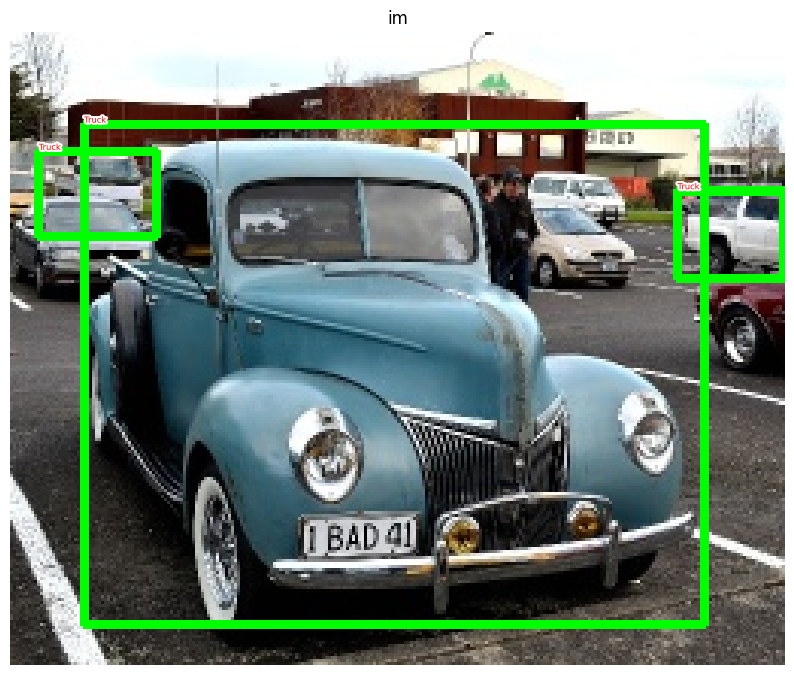

[[9, 39, 48, 67], [24, 30, 229, 195], [220, 52, 255, 81]]


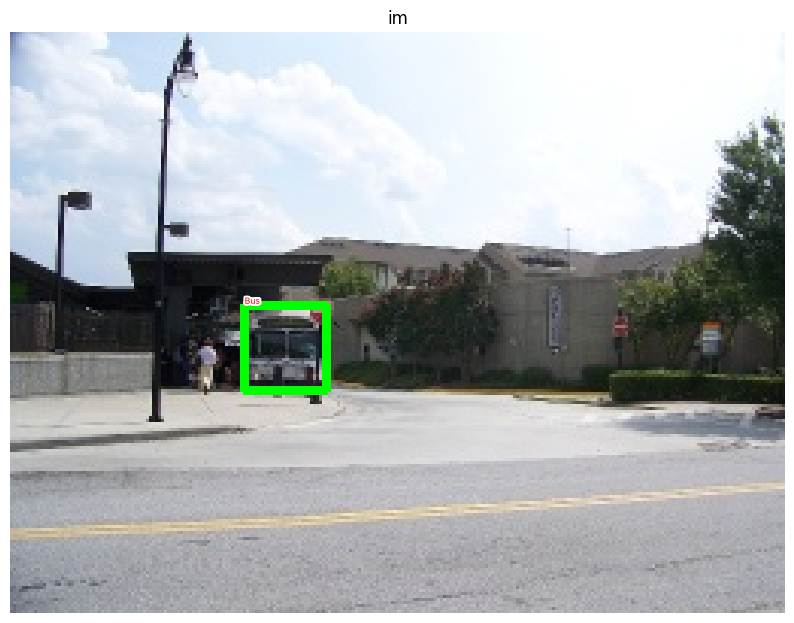

[[77, 90, 104, 118]]


In [ ]:
  ds = OpenImages(df=DF_RAW)
  im, bbs, clss, _ = ds[6]
  show(im, bbs=bbs, texts=clss, sz =10)
  print(bbs)

  im, bbs, clss, _ = ds[15]
  show(im, bbs=bbs, texts = clss, sz = 10)
  print(bbs)

/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


(24, 4)
<class 'list'>


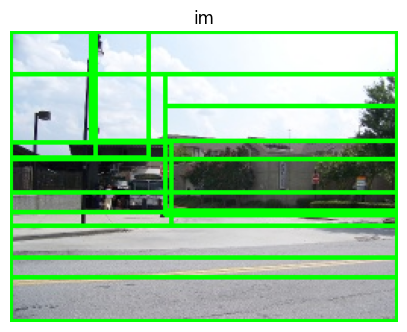

In [ ]:
candidates = extract_candidates(im)

candidates_xyxy = [[x, y, x+w, y+h] for x, y, w, h in candidates]
print(np.shape(candidates_xyxy))
print(type(candidates_xyxy))

show(im, bbs = candidates_xyxy)


In [ ]:
(im, bbs, labels, fpath) = ds[15]

H, W, _ = im.shape
candidates = extract_candidates(im)
candidates = np.array([(x, y, x+w, y+h) for x, y, w, h in candidates])

ious, rois, clss, deltas, best_ious = [], [], [], [], []
temp_best_bbs = []
ious = np.array([[extract_iou(candidate, _bb_) for candidate in candidates] for _bb_ in bbs]).T

/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


In [ ]:
for jx, candidate in enumerate(candidates):
  cx, cy, cX, cY = candidate

  candidate_ious = ious[jx]

  best_iou_at = np.argmax(candidate_ious)

  best_iou = candidate_ious[best_iou_at]

  best_ious.append(best_iou)

  best_bb = _x, _y, _X, _Y = bbs[best_iou_at]

  temp_best_bbs.append(best_bb)

  if best_iou > 0.3: clss.append(labels[best_iou_at])
  else: clss.append('background')

  delta = np.array([_x-cx, _y-cy, _X-cX, _Y-cY])/np.array([W,H,W,H])
  deltas.append(delta)
  rois.append(candidate/np.array([W,H,W,H]))

In [ ]:
best_ious_at = np.argmax(best_ious)
print("Best IoU: ", best_ious[best_ious_at])

best_candidate = candidates[best_ious_at]
best_bbs = temp_best_bbs[best_ious_at]

Best IoU:  0.1296740992629947


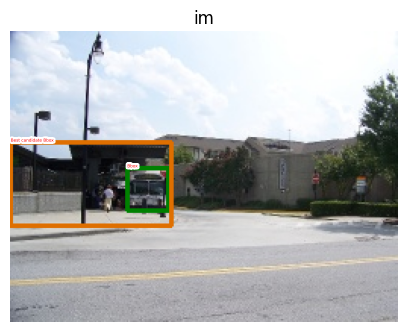

/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
/usr/local/lib/python3

In [ ]:
candidates = extract_candidates(im)

show(im, bbs = [best_bbs, best_candidate], confs= [0, 0.5], texts = ['Bbox', 'Best candidate Bbox'])

FPATHS, GTBBS, CLSS, DELTAS, ROIS, IOUS = [], [], [], [], [], []
N = 500

for ix, (im, bbs, labels, fpath) in enumerate(ds):
  if (ix==N):
    break

  H, W, _ = im.shape
  candidates = extract_candidates(im)

  candidates = np.array([(x, y, x+w, y+h) for x, y, w, h in candidates])

  ious, rois, clss, deltas = [], [], [], []

  ious = np.array([[extract_iou(candidate, _bb_) for candidate in candidates] for _bb_ in bbs]).T

  for jx, candidate in enumerate(candidates):
    cx, cy, cX, cY = candidate

    candidate_ious = ious[jx]

    best_ious_at = np.argmax(candidate_ious)

    best_iou = candidate_ious[best_ious_at]

    best_bb = _x, _y, _X, _Y = bbs[best_iou_at]

    if best_iou > 0.3 : clss.append(labels[best_ious_at])
    else: clss.append('background')

    delta = np.array([_x-cx, _y-cy, _X-cX, _Y-cY]) / np.array([W,H,W,H])

    deltas.append(delta)
    rois.append(candidate/np.array([W,H,W,H]))

  FPATHS.append(fpath)
  IOUS.append(ious)
  ROIS.append(rois)
  CLSS.append(clss)
  DELTAS.append(deltas)
  GTBBS.append(bbs)

In [ ]:
import os
FPATHS = [f'{IMAGE_ROOT}/{os.path.splitext(os.path.basename(f))[0]}.jpg' for f in FPATHS]

FPATHS, GTBBS, CLSS, DELTAS, ROIS = [item for item in [FPATHS, GTBBS, CLSS, DELTAS, ROIS]]

['/root/.cache/kagglehub/datasets/sixhky/open-images-bus-trucks/versions/1/images/images/0000599864fd15b3.jpg', '/root/.cache/kagglehub/datasets/sixhky/open-images-bus-trucks/versions/1/images/images/00006bdb1eb5cd74.jpg', '/root/.cache/kagglehub/datasets/sixhky/open-images-bus-trucks/versions/1/images/images/00010bf498b64bab.jpg', '/root/.cache/kagglehub/datasets/sixhky/open-images-bus-trucks/versions/1/images/images/00013f14dd4e168f.jpg', '/root/.cache/kagglehub/datasets/sixhky/open-images-bus-trucks/versions/1/images/images/0002914fa805e227.jpg', '/root/.cache/kagglehub/datasets/sixhky/open-images-bus-trucks/versions/1/images/images/00036603fa39fa85.jpg', '/root/.cache/kagglehub/datasets/sixhky/open-images-bus-trucks/versions/1/images/images/0004d5a9dd44ab6a.jpg', '/root/.cache/kagglehub/datasets/sixhky/open-images-bus-trucks/versions/1/images/images/0005f203463a13a8.jpg', '/root/.cache/kagglehub/datasets/sixhky/open-images-bus-trucks/versions/1/images/images/00066517f9d814f9.jpg', 

In [ ]:
# os path

In [ ]:
from itertools import chain

def flatten(list_of_lists):
  return list(chain.from_iterable(list_of_lists))

targets = pd.DataFrame(flatten(CLSS), columns=['label'])

label2target = {l : t for t, l in enumerate(targets['label'].unique())}
target2label = {t : l for l, t in label2target.items()}

background_class = label2target['background']

print("The label to target values dictionary formed is: ", label2target)

normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

def preprocess_image(img):
  img = torch.tensor(img).permute(2,0,1)
  img = normalize(img)
  return img.to(device).float()

def decode(_y):
  _, preds = _y.max(-1)
  return preds




The label to target values dictionary formed is:  {'background': 0, 'Bus': 1, 'Truck': 2}


In [ ]:
# @title
class RCNNDataset(Dataset):
  def __init__(self, fpaths, rois, labels, deltas, gtbbs):
    self.fpaths = fpaths
    self.rois = rois
    self.labels = labels
    self.deltas = deltas
    self.gtbbs = gtbbs

  def __len__(self): return len(self.fpaths)

  def __getitem__(self, ix):
    fpath = str(self.fpaths[ix])
    image = cv2.imread(fpath, 1)[...,::-1]
    H, W, _ = image.shape
    sh = np.array([W, H, W, H])
    gtbbs = self.gtbbs[ix]
    rois = self.rois[ix]

    bbs = (np.array(rois)*sh).astype(np.uint16)
    labels = self.labels[ix]
    deltas = self.deltas[ix]

    crops = [image[y:Y, x:X] for (x, y, X, Y) in bbs]
    return image, crops, bbs, labels, deltas, gtbbs, fpath

  def collate_fn(self, batch):
    input, rois, rixs, labels, deltas = [], [], [], [], []

    for ix in range(len(batch)):
      image, crops, image_bbs, image_labels, image_deltas, image_gt_bbs, image_fpath = batch[ix]

      crops = [cv2.resize(crop, (224, 224)) for crop in crops]
      crops = [preprocess_image(crop/255.)[None] for crop in crops]

      input.extend(crops)
      labels.extend([label2target[c] for c in image_labels])
      deltas.extend(image_deltas)

    input = torch.cat(input).to(device)
    labels = torch.tensor(labels).long().to(device)
    deltas = torch.tensor(deltas).float().to(device)
    return input, labels, deltas

In [ ]:
# @title
vgg_backbone = models.vgg16(pretrained=True)
vgg_backbone.classifier = nn.Sequential()

for param in vgg_backbone.parameters():
  param.requires_grad = False

vgg_backbone.eval().to(device)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 187MB/s]


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
# @title
class RCNN(nn.Module):
  def __init__(self):
    super().__init__()
    feature_dim = 25088
    self.backbone = vgg_backbone
    self.cls_score = nn.Linear(feature_dim, len(label2target))

    self.bbox = nn.Sequential(
        nn.Linear(feature_dim, 512),
        nn.ReLU(),
        nn.Linear(512, 4),
        nn.Tanh(),
    )
    self.cel = nn.CrossEntropyLoss()
    self.sl1 = nn.L1Loss()

  def forward(self, input):
    feat = self.backbone(input)
    cls_score = self.cls_score(feat)
    bbox = self.bbox(feat)
    return cls_score, bbox
  def calc_loss(self, probs, _deltas, labels, deltas):
    detection_loss = self.cel(probs, labels)

    ixs, = torch.where(labels!=1)
    _deltas = _deltas[ixs]
    deltas = deltas[ixs]

    self.lmb = 10.0

    if len(ixs) > 0:
      regression_loss = self.sl1(_deltas, deltas)
      return detection_loss + self.lmb* regression_loss, detection_loss.detach(),  regression_loss.detach()
    else:
      regression_loss = 0
      return detection_loss + self.lmb* regression_loss, detection_loss.detach(), regression_loss


In [ ]:
# @title
def train_batch(input, model, optimizer, criterion):
  input, clss, deltas = inputs

  model.train()
  optimizer.zero_grad()
  _clss, _deltas = model(input)

  loss, loc_loss, regr_loss = criterion(_clss, _deltas, clss, deltas)

  accs = clss = decode(_clss)

  loss.backward()
  optimizer.step()

  return loss.detach(), loc_loss, regr_loss, accs.cpu().numpy()



In [ ]:
# @title
@torch.no_grad()
def validate_batch(input, model, criterion):
  input, clss, deltas = inputs

  model.eval()

  _clss, _deltas = model(input)

  loss, loc_loss, regr_loss = criterion(_clss, _deltas, clss, deltas)

  _, _clss = _clss.max(-1)
  accs = clss == _clss
  return _clss, _deltas, loss.detach(), loc_loss, regr_loss, accs.cpu().numpy()


In [ ]:
# @title
import torch.optim as optim


rcnn = RCNN().to(device)
criterion = rcnn.calc_loss

optimizer = optim.SGD(rcnn.parameters(), lr = 1e-3)

n_epochs = 5
train_losses, val_losses, train_accs, val_accs = [], [], [], []


In [ ]:
from torch.utils.data import DataLoader, random_split
rcnn_dataset = RCNNDataset(FPATHS, ROIS, CLSS, DELTAS, GTBBS)

train_size = int(0.8* len(rcnn_dataset))
test_size = len(rcnn_dataset) - train_size
train_dataset, test_dataset = random_split(rcnn_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, collate_fn=rcnn_dataset.collate_fn)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False,  collate_fn=rcnn_dataset.collate_fn)

print(f"Training size: {len(train_dataset)}")
print(f"Testing size: {len(test_dataset)}")


Training size: 400
Testing size: 100


/tmp/ipython-input-1860081501.py:42: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  deltas = torch.tensor(deltas).float().to(device)


Epoch 1/5 - Val [100/100] - Loss: 1.8957 - Acc:0.9375
Epoch 1/5 Summary:
Train Loss: 3.0288 - Train Acc: 0.7050
Val Loss: 2.4155 - Val Acc: 0.7947
--------------------------------------------------
Epoch 2/5 - Val [100/100] - Loss: 1.9660 - Acc:0.9375
Epoch 2/5 Summary:
Train Loss: 1.9750 - Train Acc: 0.7074
Val Loss: 2.2726 - Val Acc: 0.8005
--------------------------------------------------
Epoch 3/5 - Val [100/100] - Loss: 2.2627 - Acc:0.9375
Epoch 3/5 Summary:
Train Loss: 1.4790 - Train Acc: 0.7119
Val Loss: 2.2463 - Val Acc: 0.8209
--------------------------------------------------
Epoch 4/5 - Val [100/100] - Loss: 2.0759 - Acc:0.9375
Epoch 4/5 Summary:
Train Loss: 1.2399 - Train Acc: 0.7201
Val Loss: 2.2329 - Val Acc: 0.8163
--------------------------------------------------
Epoch 5/5 - Val [100/100] - Loss: 2.1486 - Acc:0.9375
Epoch 5/5 Summary:
Train Loss: 1.0850 - Train Acc: 0.7251
Val Loss: 2.1595 - Val Acc: 0.8200
--------------------------------------------------


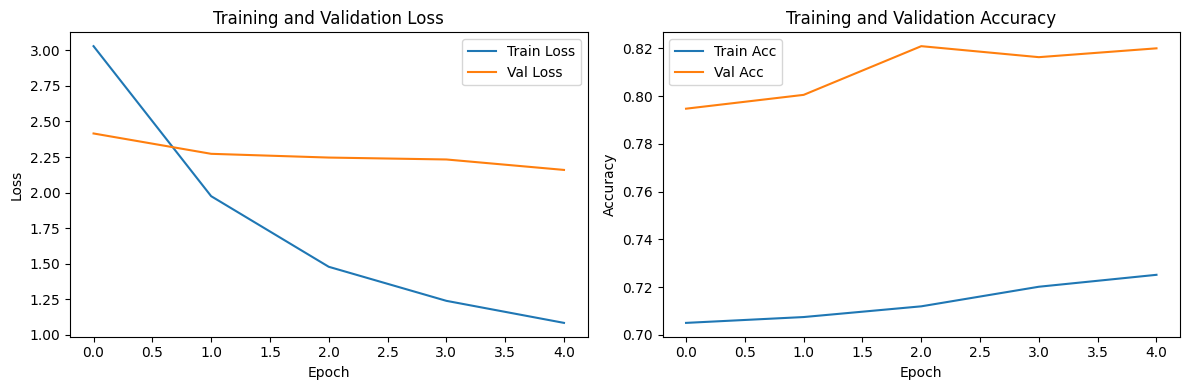

In [ ]:
for epoch in range(n_epochs):
  epoch_train_losses = []
  epoch_train_accs = []

  _n = len(train_loader)
  for ix, inputs in enumerate(train_loader):
    loss, loc_loss, regr_loss, accs = train_batch(inputs, rcnn, optimizer, criterion)

    epoch_train_losses.append(loss.item())
    epoch_train_accs.append(accs.mean())

    print(f'\rEpoch {epoch+1}/{n_epochs} - Train [{ix+1}/{_n}] - Loss: {loss.item():.4f} - Acc:{accs.mean():.4f}', end= "")

  epoch_val_losses = []
  epoch_val_accs = []
  _n = len(test_loader)

  for ix, inputs in enumerate(test_loader):
    _cls, _delta, loss, loc_loss, regr_loss, accs = validate_batch(inputs, rcnn, criterion)

    epoch_val_losses.append(loss.item())
    epoch_val_accs.append(accs.mean())

    print(f'\rEpoch {epoch+1}/{n_epochs} - Val [{ix+1}/{_n}] - Loss: {loss.item():.4f} - Acc:{accs.mean():.4f}', end= "")

  train_losses.append(np.mean(epoch_train_losses))
  train_accs.append(np.mean(epoch_train_accs))
  val_losses.append(np.mean(epoch_val_losses))
  val_accs.append(np.mean(epoch_val_accs))

  print(f'\nEpoch {epoch+1}/{n_epochs} Summary:')
  print(f'Train Loss: {train_losses[-1]:.4f} - Train Acc: {train_accs[-1]:.4f}')
  print(f'Val Loss: {val_losses[-1]:.4f} - Val Acc: {val_accs[-1]:.4f}')
  print('-'*50)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label = "Train Loss")
plt.plot(val_losses, label = "Val Loss")
plt.title("Training and Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label = "Train Acc")
plt.plot(val_accs, label = "Val Acc")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
def test_predictions(filename, show_output=True):
  img = np.array(cv2.imread(filename,1)[...,::-1])

  candidates = extract_candidates(img)
  candidates = [(x, y, x+w, y+h) for x, y, w, h in candidates]
  input = []

  for candidate in candidates:
    x, y, X, Y = candidate
    crop = cv2.resize(img[y:Y, x:X], (224, 224))
    input.append(preprocess_image(crop/255.)[None])

  input = torch.cat(input).to(device)
  with torch.no_grad():
    rcnn.eval()

    probs, deltas = rcnn(input)
    print("Shape of probs", np.shape(probs))
    print("Shape of deltas", np.shape(deltas))

    probs = torch.nn.functional.softmax(probs, -1)

    confs, clss = torch.max(probs, -1)
    print("Shape of confs", np.shape(confs))
    print("Shape of clss", np.shape(clss))
  candidates = np.array(candidates)
  confs, clss, probs, deltas = [tensor.detach().cpu().numpy() for tensor in [confs, clss, probs, deltas]]

  ixs = clss != background_class
  confs, clss, probs, deltas, candidates = [tensor[ixs] for tensor in [confs, clss, probs, deltas, candidates]]

  bbs = (candidates + deltas).astype(np.uint16)
  ixs = nms(torch.tensor(bbs.astype(np.float32)), torch.tensor(confs), 0.05)
  confs, clss, probs, deltas, candidates, bbs = [tensor[ixs] for tensor in [confs, clss, probs, deltas, candidates, bbs]]

  if len(ixs) == 1:
    confs, clss, probs, deltas, candidates, bbs = [tensor[None] for tensor in [confs, clss, probs, deltas, candidates, bbs]]
  if len(confs) == 0 and not show_output:
    return (0, 0, 224, 224), 'background', 0

  if len(confs) > 0:
    best_pred = np.argmax(confs)
    best_conf = np.max(confs)
    best_bb = bbs[best_pred]
    x, y, X, Y = best_bb

  _, ax = plt.subplots(1, 2, figsize=(20, 10))
  show(img, ax = ax[0])
  ax[0].grid(False)
  ax[0].set_title("Original Image")
  if len(confs) == 0:
    ax[1].imshow(img)
    ax[1].set_title("No Image")
    plt.show()
    return
  ax[1].set_title("Predicted Image: "+ target2label[clss[best_pred]])
  show(img, bbs=bbs.tolist(), texts=[target2label[c] for c in clss.tolist()], ax = ax[1])
  plt.show()
  return (x, y, X, Y), target2label[clss[best_pred]], best_conf


Shape of probs torch.Size([10, 3])
Shape of deltas torch.Size([10, 4])
Shape of confs torch.Size([10])
Shape of clss torch.Size([10])


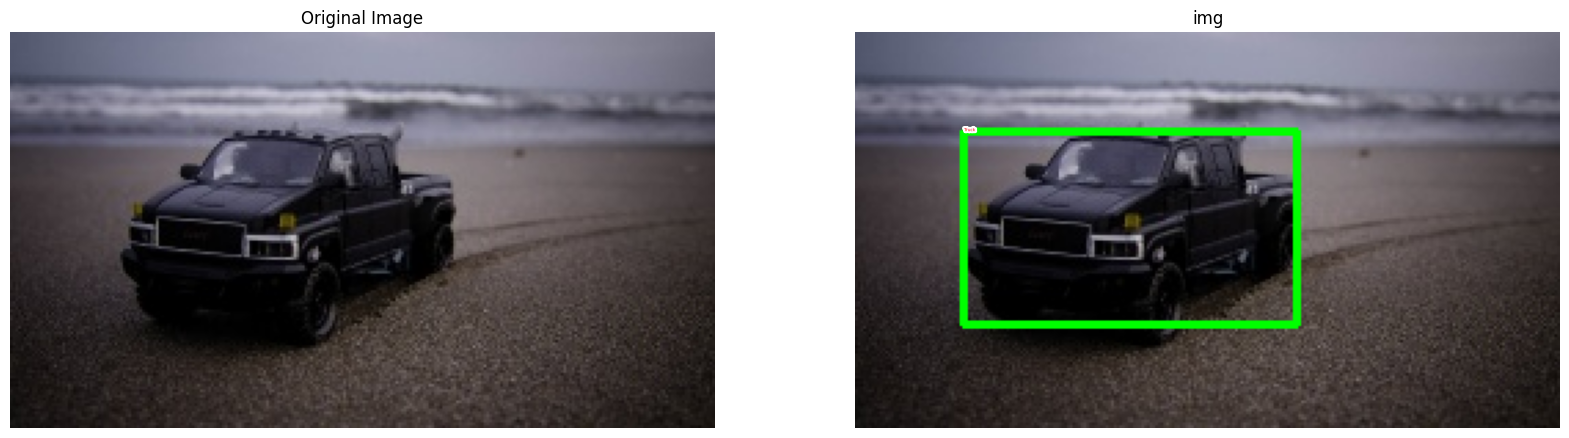

((np.uint16(39), np.uint16(36), np.uint16(160), np.uint16(106)),
 'Truck',
 np.float32(0.82812375))

In [ ]:
image, crops, bbs, labels, deltas, gtbbs, fpath = test_dataset[1]
test_predictions(fpath)